---
## <span style="color:orange">Data</span>

Connor Andrew McDavid is a Canadian professional ice hockey player and captain of the Edmonton Oilers of the National Hockey League (NHL). The data file `final.csv` provides a reduced version of Connor's game by game career data. Each row represents the stats of one game. The dataset has the following attributes:

|#| Attribute | Description |
| --- | --- | --- |
|0|`opposingTeam`|The team the player played against.|
|1|`home_or_away`|Whether a game was played home or away.|
|2|`icetime`|Log10 of total time the player played in seconds.|
|3|`gameScore`|Game score rating.|
|4|`I_F_primaryAssists`|Primary Assists the player has received on teammates' goals.|
|5|`I_F_secondaryAssists`|Secondary Assists the player has received on teammates' goals.|
|6|`log10_I_F_shotAttempts`|Log10 of shot attempts. Includes player's shots on goal, missed shots, and blocked shot attempts.|
|7|`I_F_goals`|Number of goals the player scored.|
|8|`I_F_rebounds`|Rebound shot attempts. These must occur within 3 seconds of a previous shot.|
|9|`I_F_reboundGoals`|Goals from rebound shot attempts.|
|10|`I_F_freeze`|Puck freezes after a player's shot. The  number of puck freezes by goalies after the player's unblocked shot attempts.|
|11|`I_F_playContinuedInZone`|Number of times the play continues in the offensive zone after the player's shot besides an immediate rebound shot.|
|12|`I_F_playContinuedOutsideZone`|Number of times the play goes outside the offensive zone after the player's shot.|
|13|`I_F_savedShotsOnGoal`|Number of the player's unblocked shots that were saved by the goalie.|
|14|`I_F_savedUnblockedShotAttempts`|Number of the player's unblocked shots that were saved by the goalie or missed the net.|
|15|`I_F_penalityMinutes`|Number of penalty minutes the player has received.|
|16|`log10_I_F_faceOffsWon`|Log10 of number of faceoffs the player has won.|
|17|`I_F_hits`|Number of hits the player has given.|
|18|`I_F_takeaways`|Number of takeaways the player has taken from opponents.|
|19|`I_F_giveaways`|Number of giveaways the player has given to other team.|
|20|`I_F_lowDangerGoals`|Goals from low danger shots.|
|21|`I_F_mediumDangerGoals`|Goals from medium danger shots.|
|22|`I_F_highDangerGoals`|Goals from high danger shots.|
|23|`I_F_unblockedShotAttempts`|All shot attempts that weren't blocked.|
|24|`I_F_dZoneGiveaways`|Giveaways in the team's defensive zone.|
|25|`penalityMinutesDrawn`|Number of penalty minutes the player has drawn.|
|26|`penaltiesDrawn`|Number of penalties the player has drawn.|

---
## <span style="color:orange">Global Toolbox</span>

In [1]:
import pandas as pd
import numpy as np
seed = 2023 # work with this seed throughout the notebook
np.random.seed(seed)
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

---
## Finding a model which best predicts Connor's icetime

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
import seaborn as sns

### Applying necessary transformations, dropping categorical attributes (if any), and creating the matrix of predictors and target vector.

In [3]:
df = pd.read_csv('final.csv')
df = df.drop(['opposingTeam','home_or_away'], axis=1)
y = df['icetime']
X1 = df.drop(['icetime'], axis=1)
scaler = StandardScaler()
X1 = scaler.fit_transform(X1)
print('X1 Shape:',end='')
print(X1.shape)
print('y Shape:',end='')
print(y.shape)

X1 Shape:(2725, 24)
y Shape:(2725,)


### Using a 15-component regular PCA to transform `X1` and create the scree plot. Finding the **minimum** number of PCs required in order to capture at least 80% of total variance. 

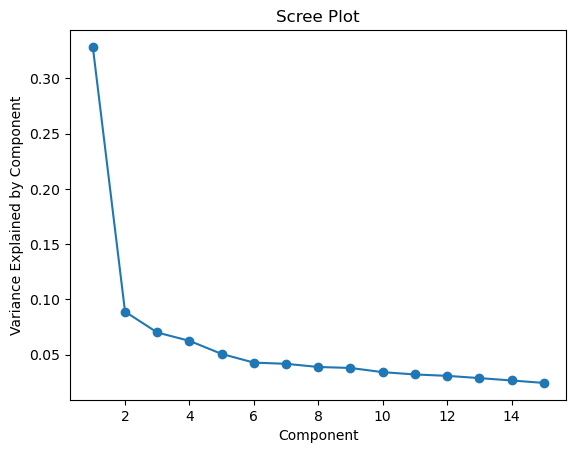

Total explained variance: 82.81 %


In [4]:
pca = PCA(n_components=15, random_state=seed)
X2 = pca.fit_transform(X1)
PCvalues = np.arange(pca.n_components_) + 1
plt.plot(PCvalues, pca.explained_variance_ratio_, 'o-')
plt.title('Scree Plot')
plt.xlabel('Component')
plt.ylabel('Variance Explained by Component')
plt.show()

pca = PCA(n_components=11, random_state=seed)
X2 = pca.fit_transform(X1)

print('Total explained variance: %.2f %%' % (np.sum(pca.explained_variance_ratio_)*100))

The minimum number of PCs required would be 11, as it is the minimum number of components to explain 80% of the variance.

### Using `KMeans` to transform and reduce the second dimension of `X1` into 16 features, with the first 15 being the distances of the instances to the k centroids and the 16th being the cluster membership of the instances. 

In [5]:
kmeans = KMeans(n_clusters=15, random_state=seed).fit(X1)
X3 = kmeans.transform(X1)
clusters = np.ndarray(2725)
for i in range(2725):
        distances = X3[:][i]
        min_dst = np.argmin(distances)
        clusters[i] = min_dst

np.c_[X3,clusters]

array([[ 7.01783957,  3.48142091,  7.63858292, ...,  6.89015347,
         6.06891439, 10.        ],
       [ 5.40597209,  2.1724383 ,  6.77380593, ...,  5.70193703,
         4.99162621,  1.        ],
       [ 5.97992714,  2.3063777 ,  6.90543505, ...,  5.89865039,
         5.16326893, 10.        ],
       ...,
       [10.73731597, 11.66377412, 10.79863587, ..., 11.01437186,
        11.84707941,  7.        ],
       [ 7.09936433,  4.68172135,  7.78034061, ...,  7.01159559,
         6.8636284 ,  4.        ],
       [ 6.91580107,  6.4778021 ,  8.1400418 , ...,  8.01911758,
         7.95382491, 12.        ]])

### Training a simple linear regression (with default arguments) once using `X1` (*i.e.*, Model 1), another time by combining `X1` and `X2` (*i.e.*, Model 2), and finally by combining `X1`, `X2`, and `X3` (*i.e.*, Model 3), using cross-validation with RMSE as the error measure to identify the best model. 

In [6]:
def rmse (y, ypr):
    return mean_squared_error(y, ypr, squared=False)

Xtrain, Xtest, ytrain, ytest = train_test_split(X1, y, random_state=seed)
LR = LinearRegression()
model1  = LR.fit(Xtrain, ytrain)
kf = KFold(n_splits=5, shuffle=True, random_state=seed)
cv_scores = cross_val_score(LR, Xtrain, ytrain, cv=kf, scoring=make_scorer(rmse))
print('Model 1 RMSE Mean: %.3f\nModel 1 RMSE STD: %.3f' % (cv_scores.mean(), cv_scores.std()))

Xtrain, Xtest, ytrain, ytest = train_test_split(np.concatenate((X1,X2),axis=1), y, random_state=seed)
model2  = LR.fit(Xtrain, ytrain)
kf = KFold(n_splits=5, shuffle=True, random_state=seed)
cv_scores = cross_val_score(LR, Xtrain, ytrain, cv=kf, scoring=make_scorer(rmse))
print('Model 2 RMSE Mean: %.3f\nModel 2 RMSE STD: %.3f' % (cv_scores.mean(), cv_scores.std()))

Xtrain, Xtest, ytrain, ytest = train_test_split(np.concatenate((X1,X2,X3),axis=1), y, random_state=seed)
model3  = LR.fit(Xtrain, ytrain)
kf = KFold(n_splits=5, shuffle=True, random_state=seed)
cv_scores = cross_val_score(LR, Xtrain, ytrain, cv=kf, scoring=make_scorer(rmse))
print('Model 3 RMSE Mean: %.3f\nModel 3 RMSE STD: %.3f' % (cv_scores.mean(), cv_scores.std()))

print('\nThe winning model is model 3 with RMSE of %.3f' % (mean_squared_error(ytrain, model3.predict(Xtrain), squared=False)))
X_final = np.concatenate((X1,X2,X3),axis=1)

Model 1 RMSE Mean: 0.571
Model 1 RMSE STD: 0.010
Model 2 RMSE Mean: 0.571
Model 2 RMSE STD: 0.011
Model 3 RMSE Mean: 0.480
Model 3 RMSE STD: 0.013

The winning model is model 3 with RMSE of 0.476


### Using the result to train an `XGBRegressor` with 150 estimators, leaving all other parameters at their default values. Report its cross-validated and generalization RMSE. 

In [7]:
model = XGBRegressor(n_estimators=150,random_state=seed)
model.fit(Xtrain, ytrain)
kf = KFold(n_splits=5, shuffle=True, random_state=seed)
cv_scores = cross_val_score(model, Xtrain, ytrain, cv=kf, scoring=make_scorer(rmse))
print('XGB CV RMSE Mean: %.3f' % (cv_scores.mean()))
print('XGB RMSE: %.3f' % (mean_squared_error(ytrain, model.predict(Xtrain), squared=False)))

XGB CV RMSE Mean: 0.358
XGB RMSE: 0.137


Now, I have achieved a better model, as shown by the lower mean squared error.

### Now, we want to see if we can make the Xgboost regressor any better. Using the cross-validated grid search function to find the best possible values for `max_depth`, and `learning_rate` for the Xgboost regressor, with these parameters at first: `max_depth` try `[2, 4, 6]`, and for `learning_rate` try `[0.05, 0.1, 0.2]`, and then finding the best parameters found and reporting the cross-validated and generalization RMSE of the fine-tuned Xgboost regressor.

In [8]:
params = dict({'max_depth': [2, 4, 6],
               'learning_rate': [0.05, 0.1, 0.2]})

gs = GridSearchCV(XGBRegressor(n_estimators=150, random_state=seed),         
                  params,              
                  cv = 5,                
                  scoring = make_scorer(rmse),
                  n_jobs = -1,         
                  refit = False,       
                  verbose = 0          
                 )

Xtrain, Xtest, ytrain, ytest = train_test_split(X_final, y, random_state=seed, test_size=0.5)
gs.fit(Xtrain, ytrain)
print(gs.best_params_)

model = XGBRegressor(n_estimators=150, learning_rate=0.2, max_depth=6, random_state=seed)
model.fit(Xtrain, ytrain)

kf = KFold(n_splits=5, shuffle=True, random_state=seed)
cv_scores = cross_val_score(model, Xtrain, ytrain, cv=kf, scoring=make_scorer(rmse))
print('XGB CV RMSE Mean: %.3f' % (cv_scores.mean()))
print('XGB RMSE: %.3f' % (mean_squared_error(ytrain, model.predict(Xtrain), squared=False)))

{'learning_rate': 0.2, 'max_depth': 6}
XGB CV RMSE Mean: 0.349
XGB RMSE: 0.122


It seems to perform slightly better than the other models. This is due to more finely tuned options.

---
## Finding out how many quality clusters are there in the data (*i.e.*, `final.csv`), and for this, in addition to the standard clustering metrics, we want to see if UMAP and t-SNE can help with the quest.

In [9]:
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
import umap
import umap.plot
from sklearn.manifold import TSNE

### Clustering the data using `KMeans` with `k` in $[2, 3, 4, 5, 6, 10]$, plotting reduction in variance versus `k` and silhouette score versus `k`. 

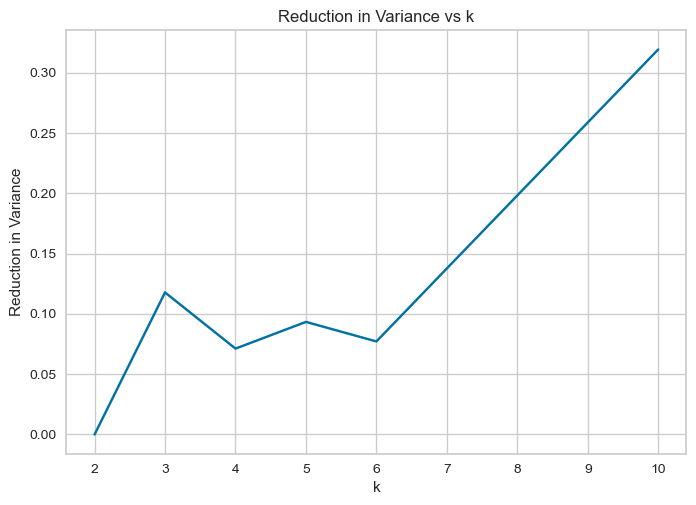

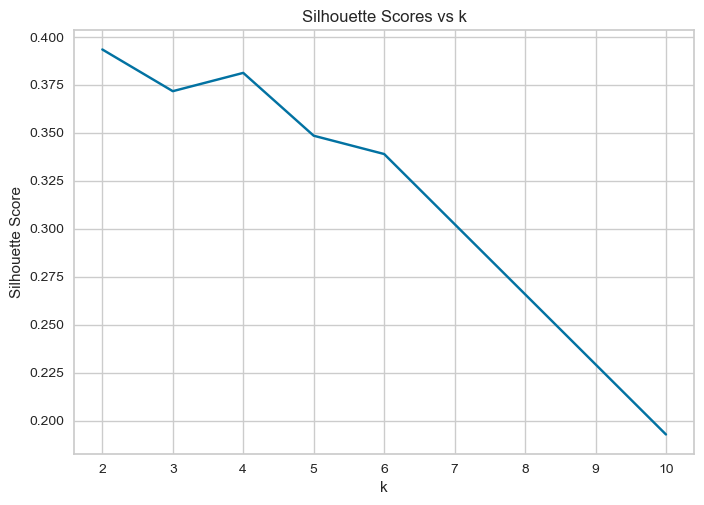

In [10]:
df = pd.read_csv('final.csv')
df = df.drop(['opposingTeam','home_or_away'], axis=1)
y = df['icetime']
scaler = StandardScaler()
X = scaler.fit_transform(df.drop(['icetime'], axis=1))
silhouetteScores = []
avgDistFromCluster = []

for k in [2,3,4,5,6,10]:
    model = KMeans(k, random_state=seed)
    model.fit(X)
    dist = model.transform(X)
    clusters = np.ndarray(2725)
    for i in range(2725):
        distances = dist[:][i]
        min_dst = np.min(distances)
        clusters[i] = min_dst
    avgDistFromCluster.append(np.mean(clusters))
    silhouetteScores.append(silhouette_score(X,model.labels_))

varReduction = np.ndarray(6)
varReduction[0] = 0
for i in range(5,0,-1):
    varReduction[i] = avgDistFromCluster[i-1]-avgDistFromCluster[i]
plt.plot([2,3,4,5,6,10], varReduction)
plt.title('Reduction in Variance vs k')
plt.xlabel('k')
plt.ylabel('Reduction in Variance')
plt.show()

plt.plot([2,3,4,5,6,10], silhouetteScores)
plt.title('Silhouette Scores vs k')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.show()

The top three k values are 2,3,4 as their silhouette scores are highest. At k=3, there seems to be a significant reduction in variance while maintaining a good silhouette score. At k=4, the silhouette score rises while still reducing variance.

### Plotting the silhouette diagrams (*i.e.*, the stacked silhouette scores for clusters) for the choices of `k` made in the previous part. 

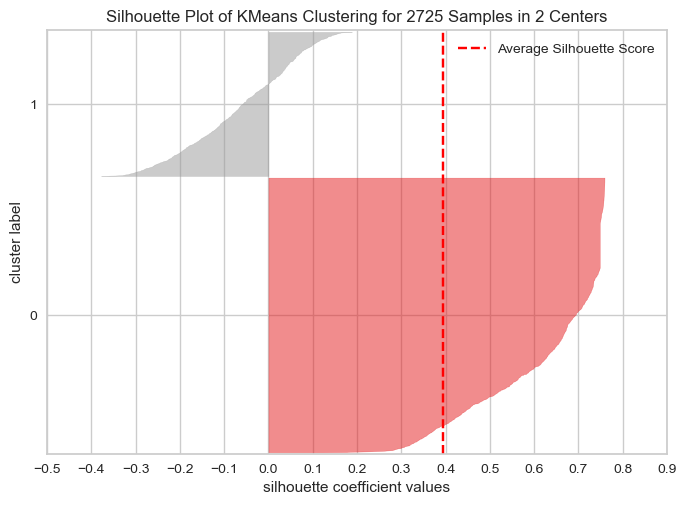

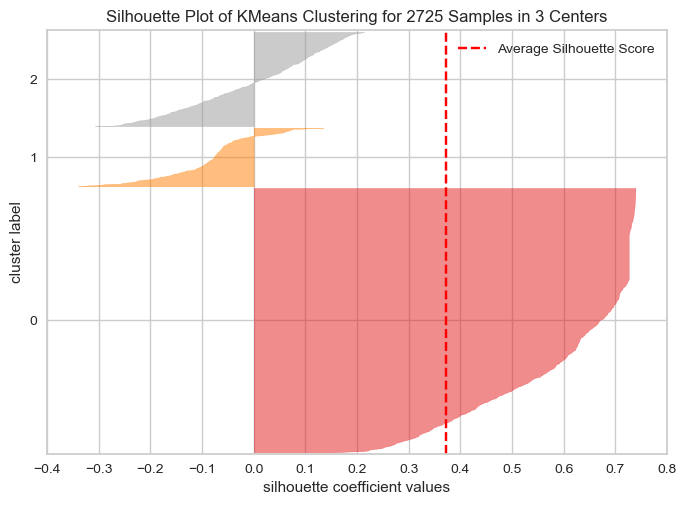

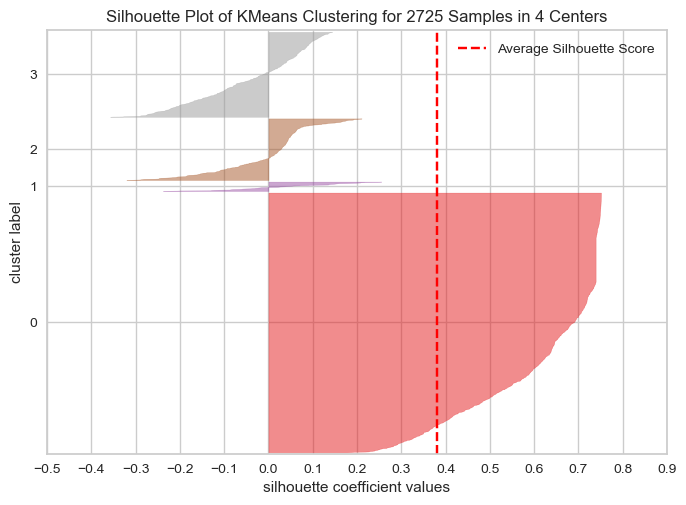

In [11]:
for k in [2,3,4]:
    model = KMeans(k, random_state=seed)
    visualizer = SilhouetteVisualizer(model)
    visualizer.fit(X)
    visualizer.show()

I will use k=4, as the clusters seem to be more well defined than the others.

### Plotting a 2-component UMAP of the data.

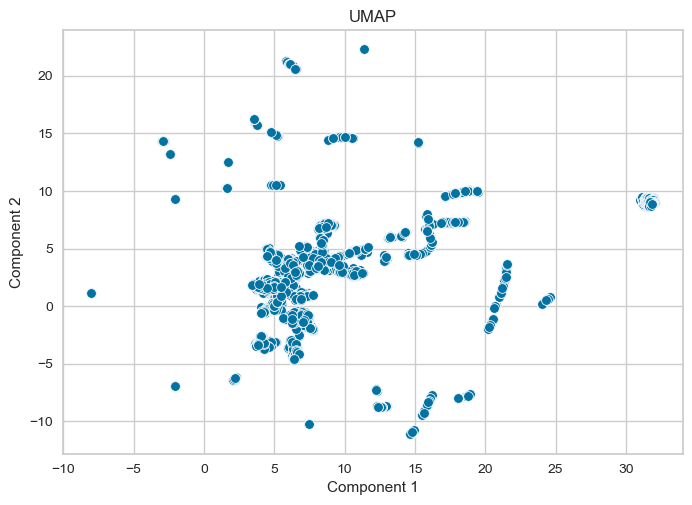

In [12]:
reducer = umap.UMAP(n_components=2,
                    n_jobs=-1, 
                    random_state=seed,
                   )

UMAP_embedding = reducer.fit_transform(X)
sns.scatterplot(x=UMAP_embedding[:, 0], y=UMAP_embedding[:, 1])
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("UMAP")
plt.show()

From the UMAPs, it seems like there are 3 clusters. We can divide the big cluster in the middle to the upper and lower cluster, and we can have the rest as the third.

### Plotting a 2-component t-SNE (with a perplexity of 100) of the data.

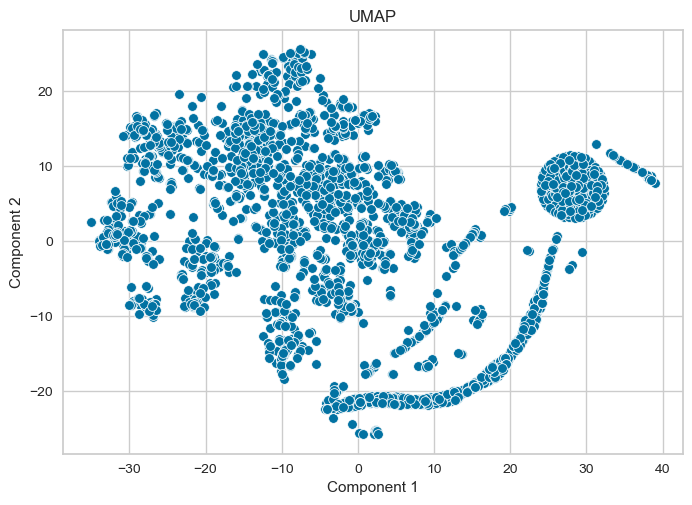

In [13]:
tSNEmapper = TSNE(n_components=2,
                  perplexity=100,    
                  random_state=seed,
                  n_jobs=-1,        
                 )
TSNE_embedding = tSNEmapper.fit_transform(X)

sns.scatterplot(x=TSNE_embedding[:, 0], y=TSNE_embedding[:, 1])
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("UMAP")
plt.show()

We may be able to extract 4 clusters here. The ball in the top right, the line coming out of the bottom of the ball, and then the points on the left seem to be divided into a top right and bottom left cluster.

Because of the silhouette plot and the t-SNE plot, I will report 4 clusters.